In [2]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [9]:
stats_df.reset_index().columns

Index(['index', 'Unnamed: 0', 'coastal_vs_bay_diff_deg', 'wind_to_mean_deg',
       'wind_wave_alignment_std', 'wind_wave_alignment_mean',
       'wind_wave_alignment_q95', 'wind_wave_alignment_annmaxmax',
       'wind_wave_alignment_q99', 'coastal_normal2_deg', 'bay_normal2_deg',
       'wind_wave_alignment_annmaxmean', 'bay_bearing_deg',
       'coastal_bearing_deg', 'wind_vs_coastal_normal_diff_deg',
       'coastal_normal1_deg', 'wind_dir_annmaxmax', 'bay_normal1_deg',
       'wind_vs_bay_normal_diff_deg', 'v10_abs_annmaxmax',
       'wind_wave_diff_annmaxmean', 'wind_wave_diff_annmaxmax', 'tide_std',
       'wind_more_bayshore_deg', 'sp_std', 'msl_std',
       'wind_more_coastalshore_deg', 'tide_mean', 'residual_annmaxmax',
       'v10_std', 'residual_std', 'tp_annmaxmax', 'wind_wave_diff_q99',
       'wind_dir_mean', 'sp_annmaxmax', 'tide_annmaxmean', 'msl_annmaxmax',
       'v10_annmaxmax', 'tide_q95', 'residual_q99', 't2m_annmaxmax',
       'tide_q99', 'mwd_std', 'tide_annmaxma

In [10]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/B_varreduction/AVERAGE_Station_pca_variables.csv")
weathercluster_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/weather_7.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_7.csv")
Static_contr = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/static_contributers.csv")

stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)
GEV_clusters["cluster_id"] = GEV_clusters["cluster"]

label_df = GEV_clusters[["station", "cluster", "cluster_id", "lat", "lon"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on=["station",], how="inner")
model_df = model_df.merge(Static_contr, on=["station","lat", "lon", "cluster"], how="inner")

In [28]:

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))

drop_cols = {"station", "cluster"}
forbidden_substrings = ("sea_level","residual","tide","lat","lon","count","missing_frac",
                        "extract_time","name","unnamed", "name", "Unnamed", 'HYRIV' , "gev", "ks", "kuiper", "r2", "dist_to_CVI_m",
                        "dist_to_morpho_m", "H", "id", "ID", "HYR", "GEOM", "POINT")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols
#model_df = model_df.groupby("station").mean(numeric_only=True)
model_df = model_df.reset_index().groupby("station").agg(
    lambda x: x.max() if pd.api.types.is_numeric_dtype(x)
    else x.mode().iloc[0]
)
# Compute cluster sizes
cluster_counts = model_df["cluster_id"].value_counts()

# Keep only stations belonging to clusters with >1 entry
model_df = model_df[model_df["cluster_id"].isin(cluster_counts[cluster_counts > 1].index)]

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster_id']

Stations for modeling: 277
cluster
3    97
1    78
4    70
6    16
2    16
Name: count, dtype: int64


In [29]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns
num_cols = X.select_dtypes(include=["number"]).columns


X_cat = pd.get_dummies(
    X[cat_cols],
    drop_first=True,   # avoids perfect collinearity
    dtype=float
)

X_num = X[num_cols]

X = pd.concat([X_num, X_cat], axis=1)
# Keep only numeric features (RF can’t take strings unless encoded)
X = X.select_dtypes(include="number").copy()

In [30]:
from sklearn.preprocessing import StandardScaler

X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

# one-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

# numeric only
X = X.select_dtypes(include="number")

# handle NaNs
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# standardize (MANDATORY for k-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y = model_df['cluster_id']

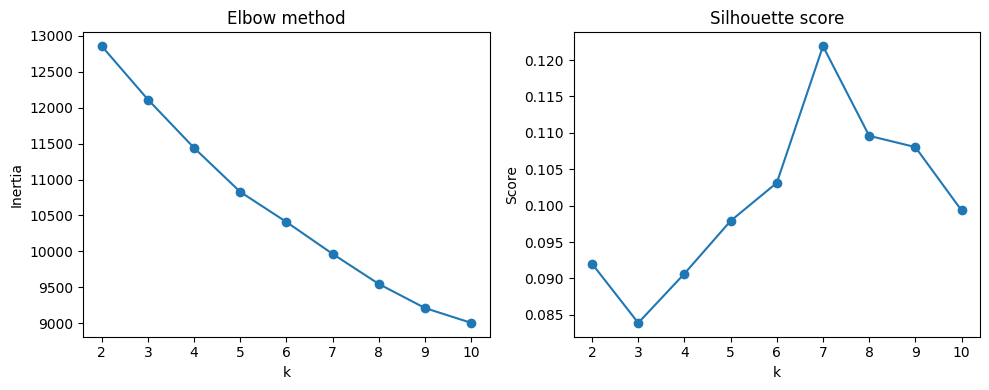

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

ks = range(2, 11)
inertia = []
silhouette = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=0)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(ks, inertia, marker="o")
ax[0].set_title("Elbow method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(ks, silhouette, marker="o")
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Score")

plt.tight_layout()
plt.show()


In [16]:
k_opt = 7

kmeans = KMeans(n_clusters=k_opt, n_init=50, random_state=0)
model_df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)


In [17]:
model_df.columns

Index(['index', 'Unnamed: 0_x', 'coastal_vs_bay_diff_deg', 'wind_to_mean_deg',
       'wind_wave_alignment_std', 'wind_wave_alignment_mean',
       'wind_wave_alignment_q95', 'wind_wave_alignment_annmaxmax',
       'wind_wave_alignment_q99', 'coastal_normal2_deg', 'bay_normal2_deg',
       'wind_wave_alignment_annmaxmean', 'bay_bearing_deg',
       'coastal_bearing_deg', 'wind_vs_coastal_normal_diff_deg',
       'coastal_normal1_deg', 'wind_dir_annmaxmax', 'bay_normal1_deg',
       'wind_vs_bay_normal_diff_deg', 'v10_abs_annmaxmax',
       'wind_wave_diff_annmaxmean', 'wind_wave_diff_annmaxmax', 'tide_std',
       'wind_more_bayshore_deg', 'sp_std', 'msl_std',
       'wind_more_coastalshore_deg', 'tide_mean', 'residual_annmaxmax',
       'v10_std', 'residual_std', 'tp_annmaxmax', 'wind_wave_diff_q99',
       'wind_dir_mean', 'sp_annmaxmax', 'tide_annmaxmean', 'msl_annmaxmax',
       'v10_annmaxmax', 'tide_q95', 'residual_q99', 't2m_annmaxmax',
       'tide_q99', 'mwd_std', 'tide_annmax

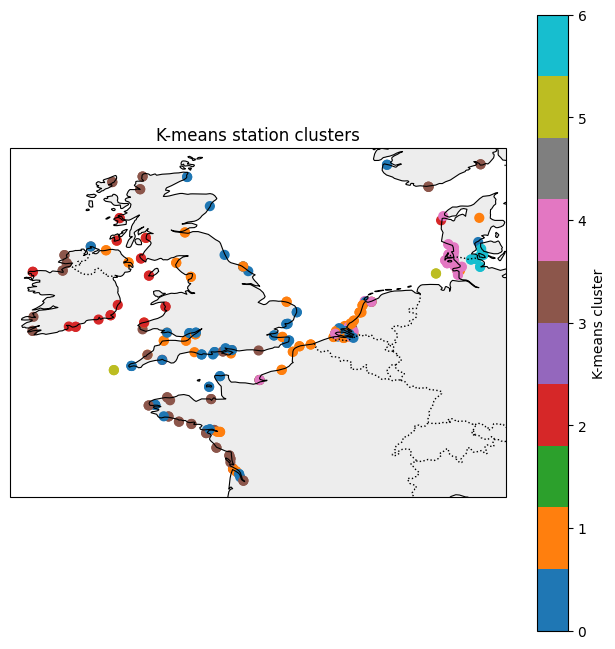

In [18]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
ax.add_feature(cfeature.OCEAN, facecolor="white")

sc = ax.scatter(
    model_df["lon"],
    model_df["lat"],
    c=model_df["kmeans_cluster"],
    cmap="tab10",
    s=40,
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, ax=ax, label="K-means cluster")
ax.set_title("K-means station clusters")
plt.show()


In [19]:
agreement_pct = (model_df["cluster_id"] == model_df["kmeans_cluster"]).mean() * 100
print(f"Exact label agreement: {agreement_pct:.1f}%")


Exact label agreement: 35.0%


In [20]:
ct = pd.crosstab(
    model_df["cluster_id"],
    model_df["kmeans_cluster"]
)
print(ct)


kmeans_cluster   0   1   2   3   4  5  6
cluster_id                              
1               26  30   3  14   2  0  3
2                3   3   0   0  10  0  0
3               26  13  17  39   0  2  0
4               10  32   1   3  22  2  0
6                1   3   1   3   2  0  6


In [21]:
best_match_pct = ct.max(axis=1).sum() / ct.values.sum() * 100
print(f"Best-match overlap: {best_match_pct:.1f}%")


Best-match overlap: 42.2%


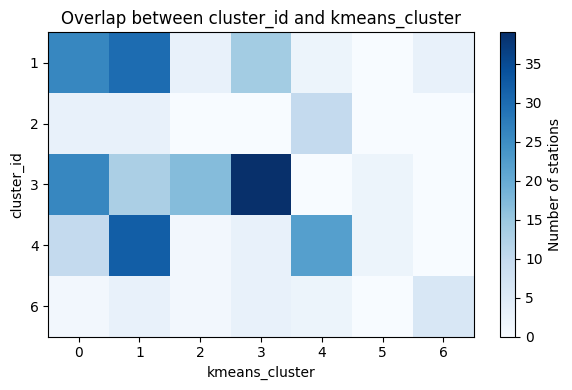

In [22]:
plt.figure(figsize=(6, 4))
plt.imshow(ct, aspect="auto", cmap="Blues")
plt.colorbar(label="Number of stations")

plt.yticks(range(len(ct.index)), ct.index)
plt.xticks(range(len(ct.columns)), ct.columns)
plt.xlabel("kmeans_cluster")
plt.ylabel("cluster_id")
plt.title("Overlap between cluster_id and kmeans_cluster")

plt.tight_layout()
plt.show()


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cluster = model_df["cluster_id"]
df = X.copy()
df["kmeans_cluster"] = cluster.values

# Per-cluster summary
means = df.groupby("kmeans_cluster").mean(numeric_only=True)
stds  = df.groupby("kmeans_cluster").std(numeric_only=True)
counts = df.groupby("kmeans_cluster").size()

# Variation across clusters (on the cluster means)
# Option A: range of means
#var_score = (means.max(axis=0) - means.min(axis=0))

# Option B (often nicer): std of means (between-cluster spread)
var_score = means.std(axis=0)

top_n = 25
top_features = var_score.sort_values(ascending=False).head(top_n).index

means_top = means[top_features]
stds_top  = stds[top_features]


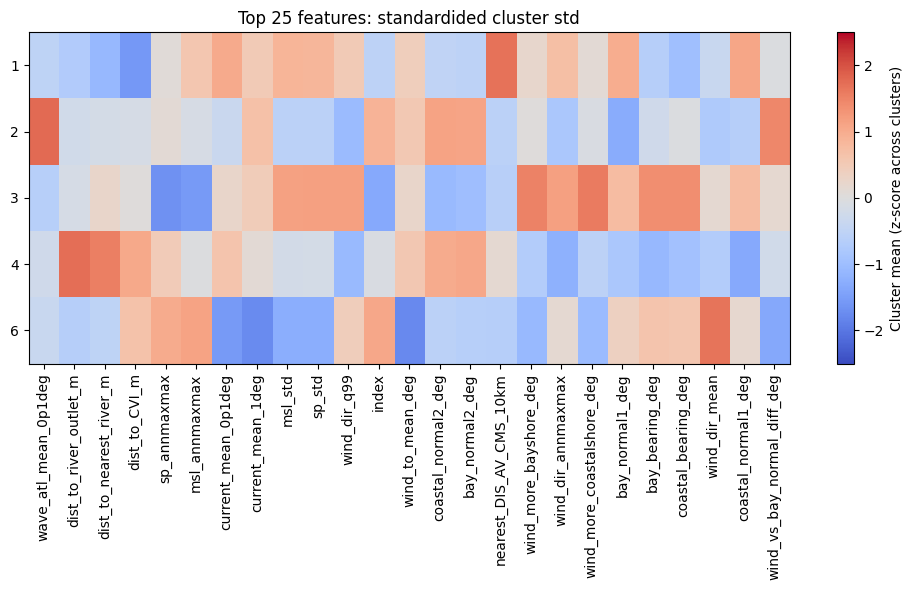

In [25]:
# Z-score across clusters (per feature)
Z = (means_top - means_top.mean(axis=0)) / (means_top.std(axis=0) + 1e-12)

plt.figure(figsize=(10, 6))
plt.imshow(Z, aspect="auto", cmap="coolwarm", vmin=-2.5, vmax=2.5)
plt.colorbar(label="Cluster mean (z-score across clusters)")

plt.yticks(range(len(Z.index)), Z.index)
plt.xticks(range(len(Z.columns)), Z.columns, rotation=90)
plt.title(f"Top {top_n} features: standardided cluster std")
plt.tight_layout()
plt.show()


In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

In [34]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=500
)

logreg.fit(X_train, y_train)

print("Train accuracy:", logreg.score(X_train, y_train))
print("Test accuracy :", logreg.score(X_test, y_test))
import pandas as pd
import numpy as np

coef = np.abs(logreg.coef_)  # shape: (n_clusters, n_features)

importance_logreg = pd.Series(
    coef.mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

print("\nTop linear predictors:\n")
print(importance_logreg.head(10))


Train accuracy: 0.9227053140096618
Test accuracy : 0.6285714285714286

Top linear predictors:

wind_dir_q99                0.698741
wave_nc_mean_0p1deg         0.651862
nearest_CATCH_SKM_10km      0.624345
current_mean_1deg           0.527164
mwd_std                     0.506789
u10_abs_annmaxmax           0.466397
wind_wave_alignment_q99     0.458897
v10_annmaxmax               0.450354
wind_wave_alignment_mean    0.443131
index                       0.440923
dtype: float64


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    class_weight="balanced",
    min_samples_leaf=5,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("RF train accuracy:", rf.score(X_train, y_train))
print("RF test accuracy :", rf.score(X_test, y_test))


RF train accuracy: 0.9468599033816425
RF test accuracy : 0.7142857142857143


In [36]:
importance_rf = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop RF predictors:\n")
print(importance_rf.head(10))



Top RF predictors:

wind_dir_q99           0.066650
v10_annmaxmax          0.058121
v10_abs_annmaxmax      0.056393
tp_annmaxmean          0.046129
current_mean_1deg      0.045452
wave_nc_mean_0p1deg    0.042365
current_mean_0p1deg    0.041717
wind_dir_annmaxmax     0.036761
index                  0.036104
mwd_std                0.033012
dtype: float64


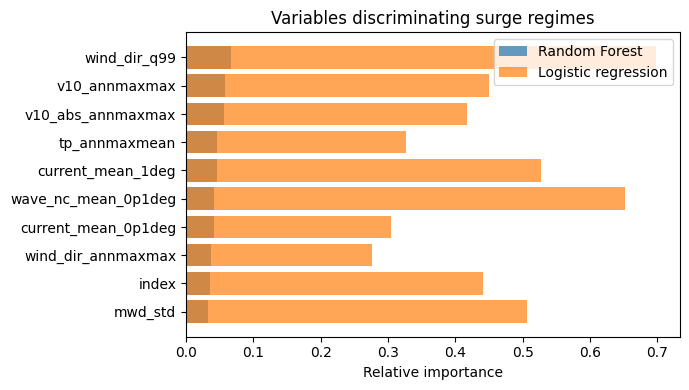

In [37]:
top_n = 10
vars_top = importance_rf.head(top_n).index

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(
    vars_top,
    importance_rf.loc[vars_top],
    alpha=0.7,
    label="Random Forest"
)

ax.barh(
    vars_top,
    importance_logreg.loc[vars_top],
    alpha=0.7,
    label="Logistic regression"
)

ax.invert_yaxis()
ax.set_xlabel("Relative importance")
ax.set_title("Variables discriminating surge regimes")
ax.legend()

plt.tight_layout()
plt.show()


In [38]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance_perm = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print("\nTop permutation importances:\n")
print(importance_perm.head(10))



Top permutation importances:

current_mean_1deg             0.011429
wind_more_coastalshore_deg    0.009286
bay_bearing_deg               0.006429
coastal_normal2_deg           0.005714
coastal_vs_bay_diff_deg       0.005000
wind_more_bayshore_deg        0.005000
bay_normal2_deg               0.005000
wind_wave_diff_q95            0.003571
index                         0.002857
wave_atl_mean_0p1deg          0.002143
dtype: float64
